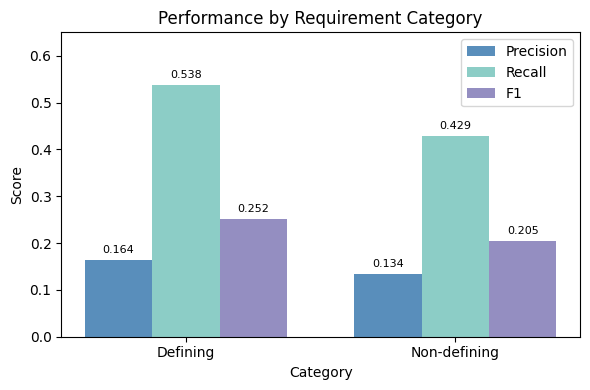

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['Defining', 'Non-defining']
precision = [0.164, 0.134]
recall = [0.538, 0.429]
f1 = [0.252, 0.205]

# Bar positions
x = np.arange(len(categories))
width = 0.25

# Colors
colors = ['#598EBB', '#8CCDC6', '#948EC1']

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Bars
bars1 = ax.bar(x - width, precision, width, label='Precision', color=colors[0])
bars2 = ax.bar(x, recall, width, label='Recall', color=colors[1])
bars3 = ax.bar(x + width, f1, width, label='F1', color=colors[2])

# Labels and title
ax.set_ylabel('Average Score across datasets')
ax.set_xlabel('Category')
ax.set_title('Performance by Requirement Category')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 0.65)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Legend
ax.legend()

# Layout
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

DATASETS = [
    "HuggingFaceFW/fineweb-edu",
    "alexfabbri/multi_news",
    # "ccdv/arxiv-summarization",
    # "ccdv/govreport-summarization",
    "ccdv/mediasum",
    # "ccdv/patent-classification",
    # "ccdv/pubmed-summarization",
    # "kritsadaK/EDGAR-CORPUS-Financial-Summarization",
    # "rohitsaxena/MovieSum",
    # "santoshtyss/uk_legislation",
    # "starmpcc/Asclepius-Synthetic-Clinical-Notes",
    # "thu-coai/esconv",
]

SCORE_COLS = ["completeness", "alignment", "faithfulness", "constraint_preservation"]
STRATEGY_ORDER = ["zero_shot", "persona", "user"]

RESULTS_ROOT = "/local/scratch/zzh2365/AUNU/results"

for raw_dataset in DATASETS:
    dataset = raw_dataset.replace("/", "_")
    csv_path = f"{RESULTS_ROOT}/{dataset}/combined_results.csv"

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"[SKIP] {dataset} — combined_results.csv not found\n")
        continue

    print(f"{'='*60}")
    print(f"Dataset: {raw_dataset}  ({len(df)} rows)")
    print(f"{'='*60}")

    avg = (
        df.groupby("strategy")[SCORE_COLS]
        .mean()
        .reindex(STRATEGY_ORDER)
        .round(4)
    )
    display(avg)
    print()


Dataset: HuggingFaceFW/fineweb-edu  (30 rows)


,completeness,alignment,faithfulness,constraint_preservation
strategy,,,,
zero_shot,0.4628,0.7734,0.3245,0.5254
persona,0.4122,0.7810,0.3272,0.5208
user,0.4516,0.7474,0.4770,0.5613



Dataset: alexfabbri/multi_news  (30 rows)


,completeness,alignment,faithfulness,constraint_preservation
strategy,,,,
zero_shot,0.4205,0.7509,0.3037,0.4332
persona,0.4699,0.7188,0.3765,0.5824
user,0.4020,0.7359,0.3769,0.5492



Dataset: ccdv/mediasum  (30 rows)


,completeness,alignment,faithfulness,constraint_preservation
strategy,,,,
zero_shot,0.4171,0.7459,0.3317,0.4292
persona,0.4696,0.7418,0.3856,0.5593
user,0.4397,0.7624,0.4439,0.4830


In [ ]:
import pandas as pd

DATASETS = [
    # "HuggingFaceFW/fineweb-edu",
    "alexfabbri/multi_news",
    # "ccdv/arxiv-summarization",
    # "ccdv/govreport-summarization",
    # "ccdv/mediasum",
    # "ccdv/patent-classification",
    # "ccdv/pubmed-summarization",
    # "kritsadaK/EDGAR-CORPUS-Financial-Summarization",
    # "rohitsaxena/MovieSum",
    # "santoshtyss/uk_legislation",
    # "starmpcc/Asclepius-Synthetic-Clinical-Notes",
    # "thu-coai/esconv",
]

SCORE_COLS = ["completeness", "alignment", "faithfulness", "constraint_preservation"]
STRATEGY_ORDER = ["zero_shot", "persona", "user", "data", "hybrid"]

RESULTS_ROOT = "/local/scratch/zzh2365/AUNU/results"

for raw_dataset in DATASETS:
    dataset = raw_dataset.replace("/", "_")
    csv_path = f"{RESULTS_ROOT}/{dataset}/combined_results.csv"

    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"[SKIP] {dataset} — combined_results.csv not found\n")
        continue

    print(f"{'='*60}")
    print(f"Dataset: {raw_dataset}  ({len(df)} rows)")
    print(f"{'='*60}")

    avg = (
        df.groupby("strategy")[SCORE_COLS]
        .mean()
        .reindex(STRATEGY_ORDER)
        .round(4)
    )
    display(avg)
    print()


In [1]:
import pandas as pd

CSV_PATH = "/local/scratch/zzh2365/AUNU/results/alexfabbri_multi_news/combined_results.csv"

df = pd.read_csv(CSV_PATH)

META_COLS = ["experiment_id", "aunu_model", "mimic_model",
             "dataset", "input_type", "max_turns"]
KEY_COLS  = ["persona", "strategy", "strategy_aunu", "task_key", "task_id"]
SCORE_COLS = ["completeness", "alignment",
              "faithfulness", "constraint_preservation"]
COUNT_COLS = ["n_predicted_units", "n_ground_truth_units", "n_matched_pairs",
              "n_missing_units", "n_hallucinated_units", "n_misaligned_units",
              "n_critical_units", "n_critical_matched"]

print(f"Loaded {len(df)} rows  x {len(df.columns)} columns")
print(f"Personas: {sorted(df['persona'].unique())}  |  Tasks: {sorted(df['task_key'].unique())}")

STRATEGY_ORDER = ["zero_shot", "persona", "user"]
df["strategy_order"] = df["strategy"].map({s: i for i, s in enumerate(STRATEGY_ORDER)})

DISPLAY_COLS = ["persona", "task_id", "strategy"] + SCORE_COLS

display(
    df[DISPLAY_COLS + ["strategy_order"]]
    .sort_values(["persona", "task_id", "strategy_order"])
    .drop(columns="strategy_order")
    .reset_index(drop=True)
)

Loaded 30 rows  x 28 columns
Personas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  |  Tasks: ['task_1', 'task_2']


,persona,task_id,strategy,completeness,alignment,faithfulness,constraint_preservation
0,1,1,zero_shot,0.5750,0.5750,0.4035,0.0000
1,1,1,persona,0.8936,0.7500,0.4767,0.0000
2,1,1,user,0.4167,0.5405,0.3770,0.0000
3,1,2,zero_shot,0.8438,0.6835,0.7381,0.1034
4,1,2,persona,0.9074,0.8305,0.6735,0.1538
5,1,2,user,0.9219,0.5566,0.5514,0.0000
6,2,1,zero_shot,0.8500,0.4322,0.5833,0.0263
7,2,1,persona,0.7679,0.3386,0.9890,0.6571
8,2,1,user,0.7455,0.4713,0.6154,0.0000
9,2,2,zero_shot,0.8214,0.6301,0.9145,0.0000


In [1]:
import pandas as pd

CSV_PATH = "/local/scratch/zzh2365/AUNU/results/HuggingFaceFW_fineweb-edu/combined_results.csv"

df = pd.read_csv(CSV_PATH)

META_COLS = ["experiment_id", "aunu_model", "mimic_model",
             "dataset", "input_type", "max_turns"]
KEY_COLS  = ["persona", "strategy", "strategy_aunu", "task_key", "task_id"]
SCORE_COLS = ["completeness", "alignment",
              "faithfulness", "constraint_preservation"]
COUNT_COLS = ["n_predicted_units", "n_ground_truth_units", "n_matched_pairs",
              "n_missing_units", "n_hallucinated_units", "n_misaligned_units",
              "n_critical_units", "n_critical_matched"]

print(f"Loaded {len(df)} rows  x {len(df.columns)} columns")
print(f"Personas: {sorted(df['persona'].unique())}  |  Tasks: {sorted(df['task_key'].unique())}")

STRATEGY_ORDER = ["zero_shot", "persona", "user"]
df["strategy_order"] = df["strategy"].map({s: i for i, s in enumerate(STRATEGY_ORDER)})

DISPLAY_COLS = ["persona", "task_id", "strategy"] + SCORE_COLS

display(
    df[DISPLAY_COLS + ["strategy_order"]]
    .sort_values(["persona", "task_id", "strategy_order"])
    .drop(columns="strategy_order")
    .reset_index(drop=True)
)

# ── Average of each metric per strategy ──────────────────────────────────────
avg_by_strategy = (
    df.groupby("strategy")[SCORE_COLS]
    .mean()
    .reindex(STRATEGY_ORDER)
    .round(4)
)
print("\nAverage scores by strategy:")
display(avg_by_strategy)

# ── Average of each metric per strategy × persona ────────────────────────────
avg_by_strategy_persona = (
    df.groupby(["strategy", "persona"])[SCORE_COLS]
    .mean()
    .round(4)
    .reset_index()
)
print("\nAverage scores by strategy × persona:")
display(avg_by_strategy_persona)


Loaded 30 rows  x 28 columns
Personas: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]  |  Tasks: ['task_1', 'task_2']


,persona,task_id,strategy,completeness,alignment,faithfulness,constraint_preservation
0,1,1,zero_shot,0.8125,0.4699,0.4077,0.0513
1,1,1,persona,0.7600,0.4691,0.9577,0.0000
2,1,1,user,0.6512,0.7568,0.7857,0.0000
3,1,2,zero_shot,0.8889,0.3357,0.4528,0.0976
4,1,2,persona,0.7143,0.5833,0.6951,0.0000
5,1,2,user,0.7593,0.7593,0.4579,0.0000
6,2,1,zero_shot,1.0000,0.4172,0.7800,0.0000
7,2,1,persona,0.9815,0.8833,0.7907,0.0000
8,2,1,user,1.0000,0.5344,0.7273,0.4000
9,2,2,zero_shot,0.9825,0.4211,0.8209,0.0000



Average scores by strategy:


,completeness,alignment,faithfulness,constraint_preservation
strategy,,,,
zero_shot,0.8678,0.5689,0.6712,0.1045
persona,0.8732,0.7210,0.8069,0.0614
user,0.8332,0.6736,0.6494,0.0786



Average scores by strategy × persona:


,strategy,persona,completeness,alignment,faithfulness,constraint_preservation
0,persona,1,0.7372,0.5262,0.8264,0.0000
1,persona,2,0.9400,0.8197,0.8016,0.0076
2,persona,3,0.8700,0.7113,0.8151,0.1428
3,persona,4,0.8636,0.7639,0.7913,0.1355
4,persona,5,0.9550,0.7838,0.8002,0.0208
5,user,1,0.7052,0.7580,0.6218,0.0000
6,user,2,0.9697,0.6042,0.6914,0.2984
7,user,3,0.8293,0.5596,0.5625,0.0882
8,user,4,0.8028,0.7168,0.8194,0.0064
9,user,5,0.8588,0.7295,0.5519,0.0000
